# PCA and Visualizations

In [1]:
OHCO  = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
CHAPS = OHCO[:2]   # chapter-level bag
BOOKS = OHCO[:1]   # book-level bag

N_COMPONENTS = 10
gradient_cmap = 'YlGnBu'

## Imports

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.linalg import norm, eigh as eig
from sklearn.decomposition import PCA
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='ticks')
%matplotlib inline

f4_dir = Path('corpus/f4')
f5_dir = Path('corpus/f5')
f5_dir.mkdir(parents=True, exist_ok=True)

## Data Load

In [3]:
LIB   = pd.read_csv('corpus/f2/LIB.csv')
VOCAB = pd.read_csv(f4_dir / 'VOCAB.csv', index_col='term_str')
TFIDF = pd.read_csv(f4_dir / 'TFIDF.csv', index_col=CHAPS)

In [4]:
# Build term_id -> term_str mapping
id_to_str = VOCAB.reset_index()[['term_str']].reset_index()
id_to_str.columns = ['term_id', 'term_str']
id_to_str = id_to_str.set_index('term_id')['term_str']

In [5]:
# Build a book-level TFIDF by summing chapter vectors
TFIDF_c = TFIDF.copy()                         # chapter-level
TFIDF_b = TFIDF.groupby(level='book_id').sum() # book-level

# Build LIB lookups keyed by book_id and (book_id, chap_num)
AUTHOR_MAP = (
    LIB[['book_id', 'author']].drop_duplicates().set_index('book_id')['author']
)
TITLE_MAP = (
    LIB[['book_id', 'book_title']].drop_duplicates().set_index('book_id')['book_title']
)

print('TFIDF_c shape:', TFIDF_c.shape)
print('TFIDF_b shape:', TFIDF_b.shape)

TFIDF_c shape: (63, 9668)
TFIDF_b shape: (9, 9668)


# Preprocess the TFIDF Matrices

## Normalize doc vector lengths

In [6]:
TFIDF_c = TFIDF_c.apply(lambda x: x / norm(x) if norm(x) != 0 else x, axis=1)
TFIDF_b = TFIDF_b.apply(lambda x: x / norm(x) if norm(x) != 0 else x, axis=1)

## center word vectors

In [7]:
COV_c = TFIDF_c.cov()
COV_b = TFIDF_b.cov()

COV_c.iloc[:5, :8].style.background_gradient(cmap=gradient_cmap)

,0,1,2,3,4,5,6,7
0,0.000013,0.000009,0.000001,-0.000001,-0.000001,-0.000001,-0.000000,-0.000000
1,0.000009,0.000019,0.000011,-0.000002,0.000005,-0.000003,-0.000000,-0.000001
2,0.000001,0.000011,0.000036,0.000030,-0.000002,0.000076,-0.000001,-0.000001
3,-0.000001,-0.000002,0.000030,0.000138,0.000029,0.000172,-0.000001,-0.000002
4,-0.000001,0.000005,-0.000002,0.000029,0.000029,-0.000003,-0.000001,-0.000001


## Decompose Matrix

In [8]:
%time eig_vals_c, eig_vecs_c = eig(COV_c)
%time eig_vals_b, eig_vecs_b = eig(COV_b)

CPU times: user 1min 10s, sys: 741 ms, total: 1min 11s
Wall time: 1min 11s


CPU times: user 1min 11s, sys: 868 ms, total: 1min 12s
Wall time: 1min 13s


## Convert to Dataframe

In [9]:
TERM_IDX = COV_b.index

EIG_VEC_c = pd.DataFrame(eig_vecs_c, index=TERM_IDX, columns=TERM_IDX)
EIG_VEC_b = pd.DataFrame(eig_vecs_b, index=TERM_IDX, columns=TERM_IDX)

EIG_VAL_c = pd.DataFrame(eig_vals_c, index=TERM_IDX, columns=['eig_val'])
EIG_VAL_c.index.name = 'term_id'

EIG_VAL_b = pd.DataFrame(eig_vals_b, index=TERM_IDX, columns=['eig_val'])
EIG_VAL_b.index.name = 'term_id'

# Select Principle components

## Combine eigenvalues and eigenvectors

In [10]:
EIG_PAIRS_c = EIG_VAL_c.join(EIG_VEC_c.T)
EIG_PAIRS_b = EIG_VAL_b.join(EIG_VEC_b.T)

In [11]:
EIG_PAIRS_b.head()

,eig_val,0,1,2,3,4,5,6,7,8,...,9658,9659,9660,9661,9662,9663,9664,9665,9666,9667
term_id,,,,,,,,,,,,,,,,,,,,,
0,-1.565154e-16,0.019182,-0.699699,0.057764,-0.041249,0.191176,0.051859,-0.025734,0.036204,0.058578,...,-0.001755,0.000665,0.000133,-0.001024,-0.000071,0.002194,0.001486,0.000562,-0.002124,0.000112
1,-1.484027e-16,-0.007586,0.228105,0.410107,0.013928,0.468703,0.275285,-0.028729,0.031172,0.106752,...,-0.004117,0.001425,0.001157,-0.002420,-0.000491,-0.002453,-0.006667,0.001542,-0.005317,0.002135
2,-1.402438e-16,0.000223,0.065421,-0.455039,-0.028511,0.128802,0.367293,-0.166174,0.005929,0.047936,...,0.007575,-0.000350,0.001192,-0.003351,-0.001967,0.003466,0.002884,-0.001328,-0.004317,-0.005222
3,-1.173800e-16,-0.000589,0.025552,-0.146467,-0.007736,0.273585,-0.052034,0.376304,0.144064,-0.043076,...,0.000862,0.002339,-0.000752,-0.000951,-0.000256,0.007679,0.000948,-0.001999,0.003532,0.003026
4,-9.765349e-17,-0.005346,0.091850,-0.139498,-0.123769,0.277202,-0.359215,0.026171,0.020185,-0.051775,...,0.004539,0.000335,-0.000433,0.005055,0.001979,0.007043,-0.002637,0.001706,-0.001855,0.001496


## Compute and Show Explained Variance

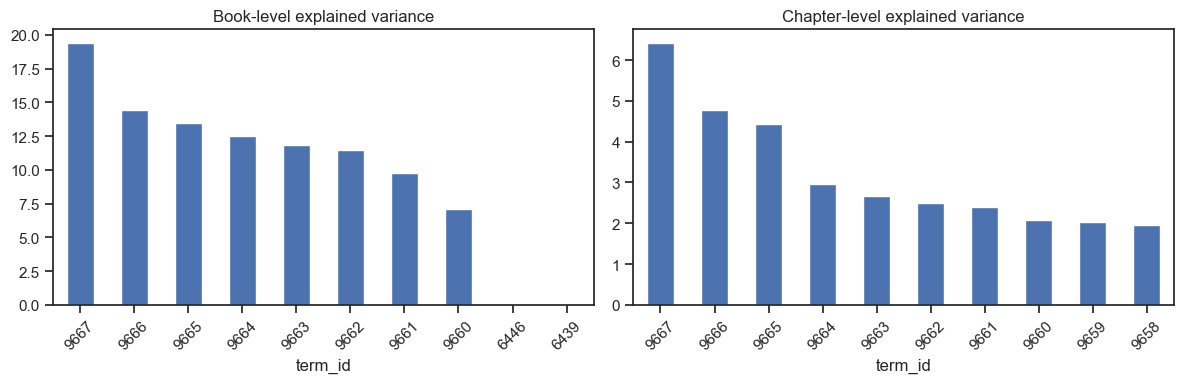

In [12]:
EIG_PAIRS_b['exp_var'] = np.round((EIG_PAIRS_b.eig_val / EIG_PAIRS_b.eig_val.sum()) * 100, 2)
EIG_PAIRS_c['exp_var'] = np.round((EIG_PAIRS_c.eig_val / EIG_PAIRS_c.eig_val.sum()) * 100, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
EIG_PAIRS_b.exp_var.sort_values(ascending=False).head(10).plot.bar(ax=axes[0], rot=45, title='Book-level explained variance')
EIG_PAIRS_c.exp_var.sort_values(ascending=False).head(10).plot.bar(ax=axes[1], rot=45, title='Chapter-level explained variance')
plt.tight_layout()
plt.show()

## Top K Components

In [13]:
TOPS_b = EIG_PAIRS_b.sort_values('exp_var', ascending=False).head(N_COMPONENTS).reset_index(drop=True)
TOPS_b.index.name = 'comp_id'
TOPS_b.index = [f'PC{i}' for i in TOPS_b.index]

TOPS_c = EIG_PAIRS_c.sort_values('exp_var', ascending=False).head(N_COMPONENTS).reset_index(drop=True)
TOPS_c.index.name = 'comp_id'
TOPS_c.index = [f'PC{i}' for i in TOPS_c.index]

TOPS_b[['eig_val', 'exp_var']].head(10)

,eig_val,exp_var
PC0,1.690938e-01,19.43
PC1,1.255781e-01,14.43
PC2,1.173300e-01,13.48
PC3,1.091847e-01,12.54
PC4,1.028427e-01,11.81
PC5,9.964713e-02,11.45
PC6,8.527315e-02,9.80
PC7,6.152030e-02,7.07
PC8,3.224400e-22,0.00
PC9,3.184861e-22,0.00


## Loadings

In [14]:
LOADINGS_b = TOPS_b[TERM_IDX].T
LOADINGS_b.index.name = 'term_id'

In [15]:
LOADINGS_b.head().style.background_gradient()

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_id,,,,,,,,,,
0,0.007478,0.000905,0.002548,-0.000067,-0.019508,-0.019385,0.000209,0.004051,0.000000,0.000000
1,0.003731,-0.000673,0.000666,0.000149,-0.013108,-0.015929,-0.004880,0.002314,-0.000006,0.000037
2,-0.002157,-0.003279,-0.002649,0.000354,0.001009,-0.004713,-0.011127,-0.003883,-0.000008,-0.000021
3,-0.006475,-0.006135,-0.005380,0.000770,0.005306,-0.006451,-0.021574,-0.005647,-0.000006,-0.000010
4,-0.003788,-0.002871,-0.002590,0.000426,0.002634,-0.003615,-0.010804,-0.001423,0.000034,-0.000026


In [16]:

LOADINGS_c = TOPS_c[TERM_IDX].T
LOADINGS_c.index.name = 'term_str'

In [17]:
for pc in ['PC0', 'PC1', 'PC2', 'PC3']:
    pos = LOADINGS_c[pc].nlargest(10).index.tolist()
    neg = LOADINGS_c[pc].nsmallest(10).index.tolist()
    
    pos_words = [id_to_str.get(int(i), i) for i in pos]
    neg_words = [id_to_str.get(int(i), i) for i in neg]
    
    print(f'{pc}+: {", ".join(pos_words)}')
    print(f'{pc}-: {", ".join(neg_words)}')
    print()

PC0+: wrote, poet, bake, irrespective, preserve, walking, plumtree, provoked, straight, welltreated
PC0-: white, accordance, damming, hundredweights, performed, filthiness, events, stubborn, resulting, occupies

PC1+: accordance, white, wrote, performed, rises, damming, performs, rebels, slacken, perished
PC1-: industriously, apples, reveals, especially, pretext, bond, applies, emasculated, individually, light

PC2+: hundredweights, filthiness, resulting, occupies, events, promoter, director, damming, dispense, wrote
PC2-: accordance, performed, performs, rises, splendid, slacken, assembled, gormandizing, industriously, reveals

PC3+: fear, assembled, rebels, abduction, straight, naught, surer, yield, regiment, pretext
PC3-: white, accordance, wrote, rises, industriously, southern, apples, broader, violated, reveals



PC0 separates utopian social imagination (Fourier) from scientific/ideological socialism
PC1 separates political theory (Luxemburg/Marx) from military practice (Mao)
PC2 captures the military-operational dimension most strongly
PC3 captures finer distinctions within the revolutionary tradition

# Project Docs onto New Subspace

Due to my lib being formatted a little differently, we have to go in at different points -- indexing

In [18]:
DCM_c = TFIDF_c.dot(TOPS_c[TERM_IDX].T)
DCM_b = TFIDF_b.dot(TOPS_b[TERM_IDX].T)


In [19]:
DCM_b['label'] = AUTHOR_MAP
DCM_b['title'] = TITLE_MAP

In [20]:
print(LIB[LIB['chap_num'].isna()][['book_id', 'filepath']])


Empty DataFrame
Columns: [book_id, filepath]
Index: []


In [21]:
DCM_c['label'] = DCM_c.apply(lambda x: AUTHOR_MAP.get(x.name[0], x.name[0]), axis=1)
DCM_c['title'] = DCM_c.apply(lambda x: TITLE_MAP.get(x.name[0], x.name[0]), axis=1)
DCM_c['chapter'] = DCM_c.apply(lambda x: f"{AUTHOR_MAP.get(x.name[0], x.name[0])} ch{x.name[1]:02d}", axis=1)

DCM_c.head().style.background_gradient(cmap=gradient_cmap)

# Visualize

In [22]:
def vis_pcs(M, a, b, prefix='PC'):
    fig = px.scatter(M, prefix + str(a), prefix + str(b),
                        color='label',
                        hover_name='title', marginal_x='box')
    fig.show()


## Chaps PC 0 and 1

In [23]:
vis_pcs(DCM_c, 0, 1)

### What's going on?
In this graph, it is evident that Mao Zedong's language is to the far left, while the other author's language is a bit different and further out. 

## Chaps, PC 1 and 2

In [24]:
vis_pcs(DCM_c, 1, 2)

## Chaps, PC 2 and 3

In [25]:
vis_pcs(DCM_c, 2, 3)

## Compare to sci kit learn

In [26]:
pca_engine = PCA(n_components=10)

In [27]:
# scikit-learn PCA cannot compute more components than min(n_samples, n_features)
n_components = min(N_COMPONENTS, TFIDF_b.shape[0], TFIDF_b.shape[1])
pca_engine = PCA(n_components=n_components)

DCM_sk_b = pd.DataFrame(
	pca_engine.fit_transform(TFIDF_b),
	index=TFIDF_b.index,
	columns=[f'PC{i}' for i in range(n_components)]
)

DCM_sk_b['label'] = DCM_sk_b.index.map(AUTHOR_MAP)
DCM_sk_b['title'] = DCM_sk_b.index.map(TITLE_MAP)

In [28]:
DCM_sk_b.head().style.background_gradient()

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,label,title
book_id,,,,,,,,,,,
fourier_selections,-0.269342,0.269480,0.507949,-0.632395,-0.009975,0.143878,0.046830,-0.021516,-0.000000,Charles Fourier,Selections from his Writings
luxemburg_reform-or-revolution,-0.422228,-0.237671,-0.200345,0.030669,0.178566,-0.237464,0.607379,-0.057710,-0.000000,Rosa Luxemburg,Reform or Revolution
mao_correcting-mistaken-ideas,0.359623,0.032308,0.085016,-0.002074,-0.570572,-0.549375,-0.005058,0.070880,-0.000000,Mao Zedong,On Correcting Mistaken Ideas in the Party
mao_on-guerrilla-warfare,0.280655,0.272998,0.430205,0.451150,0.484113,-0.128954,-0.016562,0.099614,-0.000000,Mao Zedong,On Guerrilla Warfare
mao_on-practice,-0.205449,0.705405,-0.554297,0.070268,-0.046874,0.086585,-0.106869,-0.016920,-0.000000,Mao Zedong,On Practice


In [29]:
DCM_sk_c = pd.DataFrame(pca_engine.fit_transform(TFIDF_c), index=TFIDF_c.index)
DCM_sk_c.columns = ['PC{}'.format(i) for i in DCM_sk_c.columns]
DCM_sk_c['label'] = DCM_sk_c.index.get_level_values('book_id').map(AUTHOR_MAP)
DCM_sk_c['title'] = DCM_sk_c.index.get_level_values('book_id').map(TITLE_MAP)

In [30]:
DCM_sk_c.head().style.background_gradient()

In [31]:
N_COMPONENTS = 10

# Table 1: Documents x Components (DCM)
# Rows = chapters (book_id, chap_num), Columns = PC0..PC9
pc_cols = [f'PC{i}' for i in range(N_COMPONENTS)]
DCM_c[pc_cols].to_csv(f5_dir / 'PCA_DCM_chaps.csv')

# Table 2: Components x Terms — the eigenvector weights (loadings)
# Rows = PC0..PC9, Columns = term_str
TOPS_c[TERM_IDX].to_csv(f5_dir / 'PCA_TCM_chaps.csv')

# Table 3: VOCAB_F5 — start the cumulative vocab table with PCA loadings
VOCAB_F5 = VOCAB.join(LOADINGS_c, how='left')
VOCAB_F5.to_csv(f5_dir / 'VOCAB_F5.csv')


In [32]:
for pc in ['PC0', 'PC1', 'PC2', 'PC3']:
    pos = LOADINGS_c[pc].nlargest(10).index.tolist()
    neg = LOADINGS_c[pc].nsmallest(10).index.tolist()
    
    pos_words = [id_to_str.get(int(i), i) for i in pos]
    neg_words = [id_to_str.get(int(i), i) for i in neg]
    
    print(f'{pc}+: {", ".join(pos_words)}')
    print(f'{pc}-: {", ".join(neg_words)}')
    print()

PC0+: wrote, poet, bake, irrespective, preserve, walking, plumtree, provoked, straight, welltreated
PC0-: white, accordance, damming, hundredweights, performed, filthiness, events, stubborn, resulting, occupies

PC1+: accordance, white, wrote, performed, rises, damming, performs, rebels, slacken, perished
PC1-: industriously, apples, reveals, especially, pretext, bond, applies, emasculated, individually, light

PC2+: hundredweights, filthiness, resulting, occupies, events, promoter, director, damming, dispense, wrote
PC2-: accordance, performed, performs, rises, splendid, slacken, assembled, gormandizing, industriously, reveals

PC3+: fear, assembled, rebels, abduction, straight, naught, surer, yield, regiment, pretext
PC3-: white, accordance, wrote, rises, industriously, southern, apples, broader, violated, reveals

